In [1]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt

print("Setup works perfectly!")

Setup works perfectly!


# Smart Plant Irrigation System Using Fuzzy Logic

Welcome to this tutorial on building a Fuzzy Inference System (FIS) using **scikit-fuzzy**. 

### The Problem
Traditional automated irrigation systems use rigid threshold values (e.g., if soil moisture < 30%, turn on pump 100%). However, real-world agricultural conditions are uncertain and continuous. By using fuzzy logic, we can combine multiple uncertain inputs—like **Soil Moisture** and **Ambient Temperature**—to smoothly regulate our **Water Pump Speed**.

In [2]:
# Import required libraries
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt

# Enable inline plotting for Jupyter Notebooks
%matplotlib inline

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
# 1. Define Input Variables (Antecedents) and Output Variable (Consequent)
soil_moisture = ctrl.Antecedent(np.arange(0, 101, 1), 'soil_moisture')
temperature = ctrl.Antecedent(np.arange(10, 41, 1), 'temperature')
water_pump = ctrl.Consequent(np.arange(0, 101, 1), 'water_pump')

print("Fuzzy variables initialized successfully.")

Fuzzy variables initialized successfully.


c:\Users\Hitha N\AppData\Local\Programs\Python\Python311\Lib\site-packages\skfuzzy\control\fuzzyvariable.py:125: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


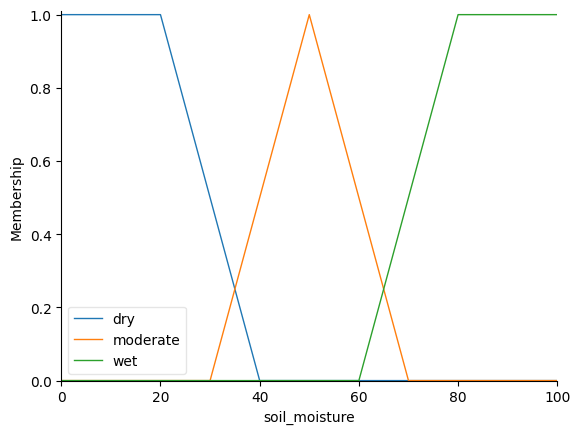

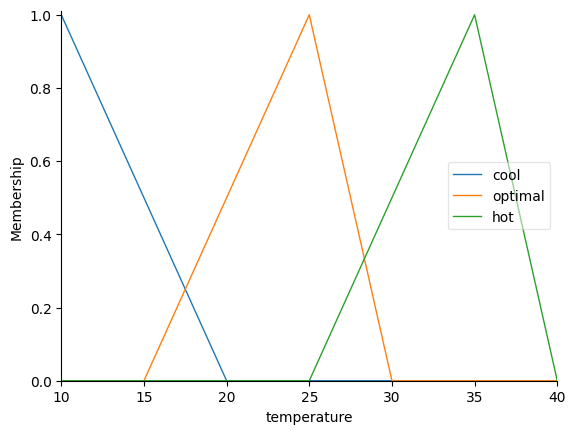

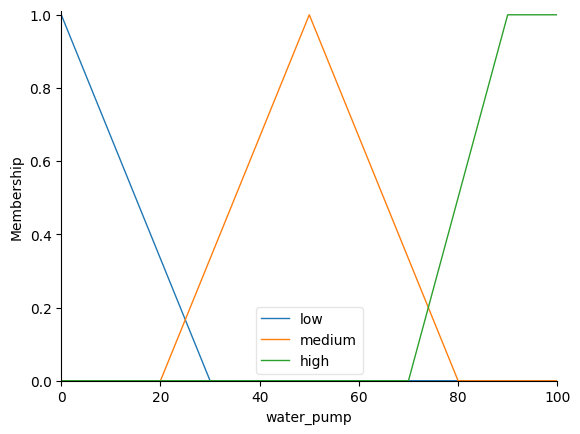

In [4]:
# 2. Define Membership Functions for Soil Moisture (%)
soil_moisture['dry'] = fuzz.trapmf(soil_moisture.universe, [0, 0, 20, 40])
soil_moisture['moderate'] = fuzz.trimf(soil_moisture.universe, [30, 50, 70])
soil_moisture['wet'] = fuzz.trapmf(soil_moisture.universe, [60, 80, 100, 100])

# Define Membership Functions for Temperature (°C)
temperature['cool'] = fuzz.trimf(temperature.universe, [10, 10, 20])
temperature['optimal'] = fuzz.trimf(temperature.universe, [15, 25, 30])
temperature['hot'] = fuzz.trimf(temperature.universe, [25, 35, 40])

# Define Membership Functions for Water Pump Speed (%)
water_pump['low'] = fuzz.trimf(water_pump.universe, [0, 0, 30])
water_pump['medium'] = fuzz.trimf(water_pump.universe, [20, 50, 80])
water_pump['high'] = fuzz.trapmf(water_pump.universe, [70, 90, 100, 100])

# Visualize membership functions
soil_moisture.view()
temperature.view()
water_pump.view()

In [5]:
# 3. Define the Fuzzy Rule Base
# Rule 1: If soil is dry OR temperature is hot, pump water at HIGH speed.
rule1 = ctrl.Rule(soil_moisture['dry'] | temperature['hot'], water_pump['high'])

# Rule 2: If soil is moderate AND temperature is optimal, pump water at MEDIUM speed.
rule2 = ctrl.Rule(soil_moisture['moderate'] & temperature['optimal'], water_pump['medium'])

# Rule 3: If soil is wet, pump water at LOW speed (save water).
rule3 = ctrl.Rule(soil_moisture['wet'], water_pump['low'])

print("Fuzzy rules established successfully.")

Fuzzy rules established successfully.


In [6]:
# 4. Create Control System and Simulation Environment
irrigation_ctrl = ctrl.ControlSystem([rule1, rule2, rule3])
irrigation_simulation = ctrl.ControlSystemSimulation(irrigation_ctrl)

# 5. Provide Test Inputs (e.g., Soil Moisture = 22%, Temperature = 34°C)
irrigation_simulation.input['soil_moisture'] = 22
irrigation_simulation.input['temperature'] = 34

# Compute the fuzzy logic output
irrigation_simulation.compute()

# Output the crisp result
output_speed = irrigation_simulation.output['water_pump']
print("--- Simulation Results ---")
print(f"Input Soil Moisture: 22% (Dry)")
print(f"Input Temperature: 34°C (Hot)")
print(f"Recommended Water Pump Speed: {output_speed:.2f}%")

--- Simulation Results ---
Input Soil Moisture: 22% (Dry)
Input Temperature: 34°C (Hot)
Recommended Water Pump Speed: 88.86%


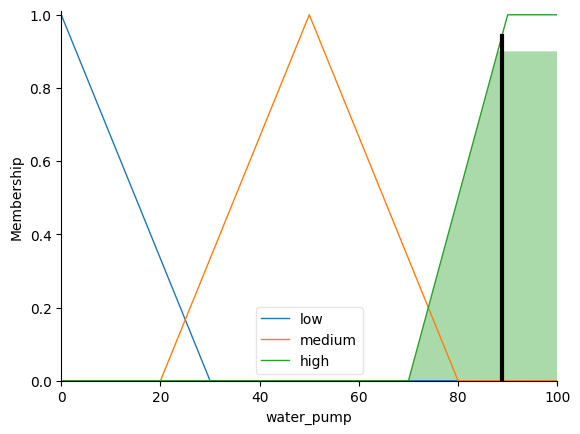

In [7]:
# 6. Visualize the continuous output and defuzzification result
water_pump.view(sim=irrigation_simulation)